In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("Daily_Cal_Req (1).csv")


In [2]:
df.head()

,Age,Gender,Height_cm,Weight_kg,Activity_Level,Sleep_Hours,Water_Intake_L,Goal,Diet_Type,Daily_Calorie_Requirement
0,58.0,Male,151.0,80.0,Light,5.6,3.6,Gain,Veg,2306
1,46.0,Female,150.0,65.0,Active,6.2,1.5,Maintain,Veg,2064
2,53.0,Female,190.0,91.0,Very Active,5.5,1.2,Gain,Non-Veg,3476
3,60.0,Female,154.0,66.0,Very Active,8.1,1.6,Gain,Vegan,2207
4,35.0,Male,163.0,85.0,Light,7.8,2.4,Gain,Jain,2636


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        225 non-null    float64
 1   Gender                     225 non-null    object 
 2   Height_cm                  250 non-null    float64
 3   Weight_kg                  250 non-null    float64
 4   Activity_Level             250 non-null    object 
 5   Sleep_Hours                250 non-null    float64
 6   Water_Intake_L             250 non-null    float64
 7   Goal                       250 non-null    object 
 8   Diet_Type                  250 non-null    object 
 9   Daily_Calorie_Requirement  250 non-null    int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 19.7+ KB


,Age,Height_cm,Weight_kg,Sleep_Hours,Water_Intake_L,Daily_Calorie_Requirement
count,225.000000,250.00000,250.000000,250.000000,250.000000,250.00000
mean,40.066667,170.50800,78.168000,7.158000,2.775200,2462.46000
std,12.006695,11.44438,18.307606,1.424272,0.965564,553.84209
min,18.000000,150.00000,45.000000,4.500000,1.000000,1167.00000
25%,30.000000,161.00000,64.000000,6.000000,2.000000,2088.50000
50%,40.000000,171.00000,81.000000,7.200000,2.700000,2404.00000
75%,51.000000,180.00000,91.000000,8.475000,3.600000,2823.50000
max,60.000000,190.00000,110.000000,9.500000,4.500000,4107.00000


<Axes: xlabel='Diet_Type'>

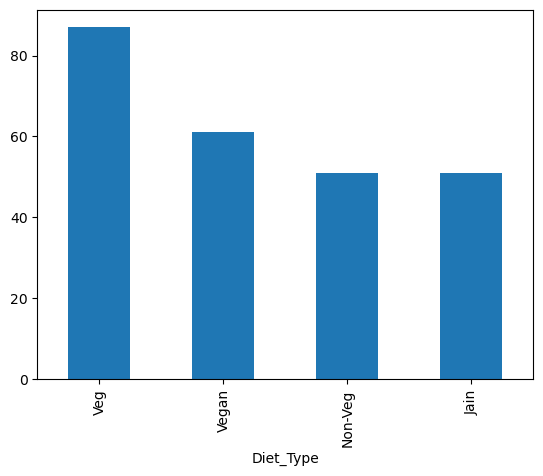

In [4]:
df['Diet_Type'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

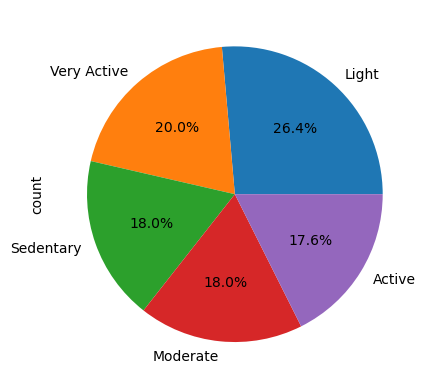

In [5]:
df['Activity_Level'].value_counts().plot(kind='pie', autopct='%1.1f%%')

<Axes: xlabel='Age_Group'>

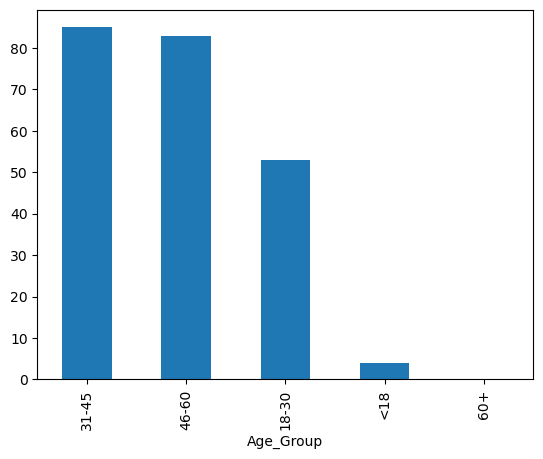

In [6]:
bins = [0,18,30,45,60,100]
labels = ['<18','18-30','31-45','46-60','60+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
df['Age_Group'].value_counts().plot(kind='bar')

In [7]:
df['Gender'].value_counts(normalize=True)*100

Gender
Male      58.222222
Female    41.777778
Name: proportion, dtype: float64

<Axes: xlabel='Goal'>

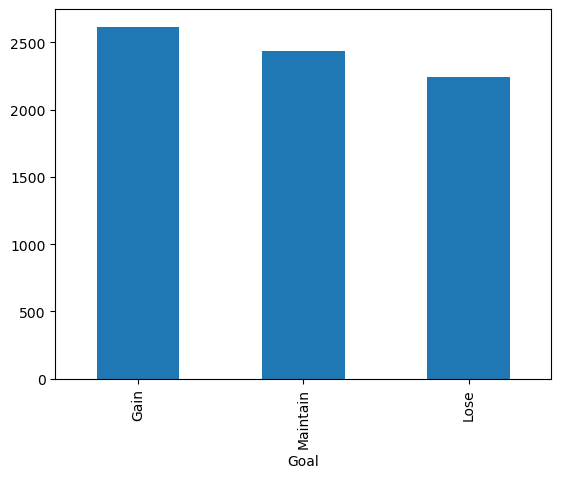

In [9]:
df.groupby('Goal')['Daily_Calorie_Requirement'].mean().sort_values(ascending=False).plot(kind='bar')

,Age,Daily_Calorie_Requirement
Age,1.000000,-0.113187
Daily_Calorie_Requirement,-0.113187,1.000000


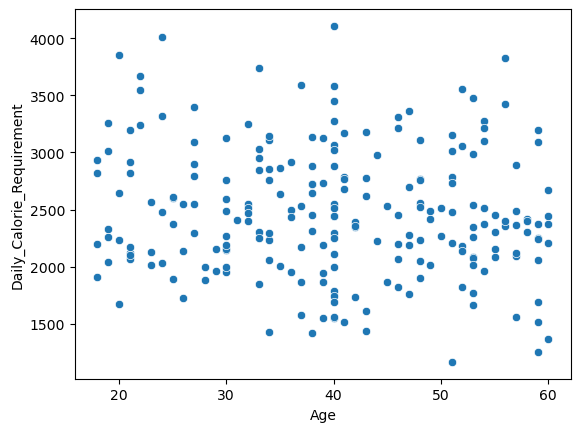

In [12]:
sns.scatterplot(x='Age', y='Daily_Calorie_Requirement', data=df)
df[['Age','Daily_Calorie_Requirement']].corr()

<Axes: xlabel='Activity_Level', ylabel='Water_Intake_L'>

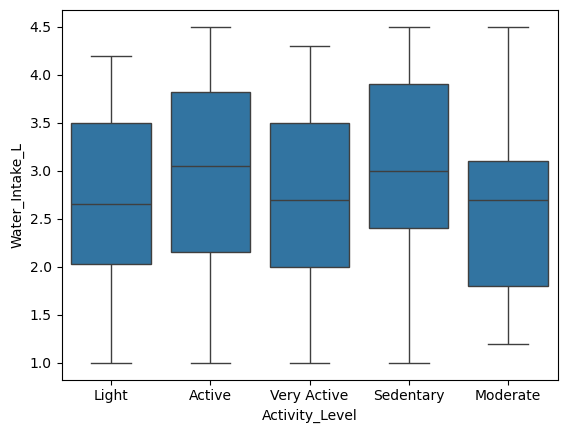

In [14]:
sns.boxplot(x='Activity_Level', y='Water_Intake_L', data=df)

<Axes: xlabel='Activity_Level', ylabel='Daily_Calorie_Requirement'>

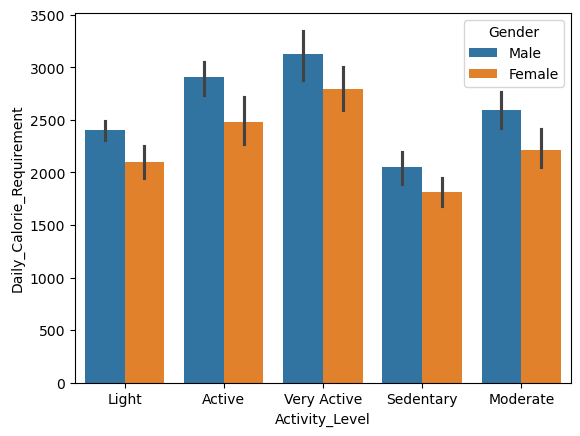

In [15]:
sns.barplot(x='Activity_Level', y='Daily_Calorie_Requirement', hue='Gender', data=df)

<Axes: >

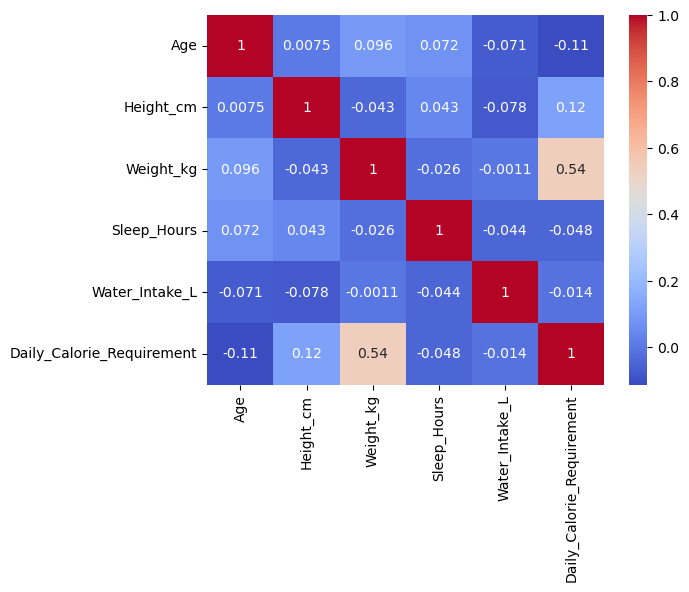

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

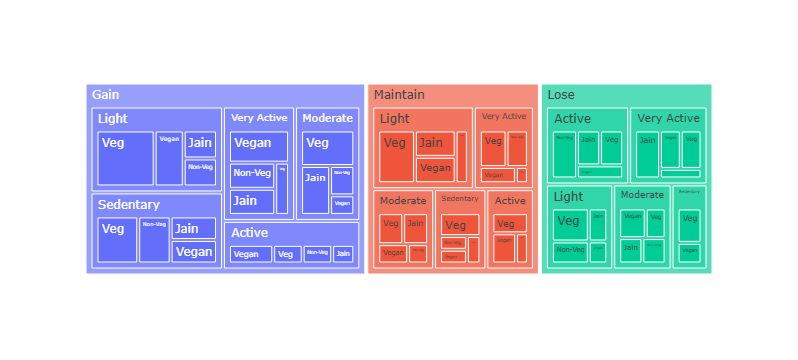

In [17]:
fig = px.treemap(df, path=['Goal','Activity_Level','Diet_Type'])
fig.show()

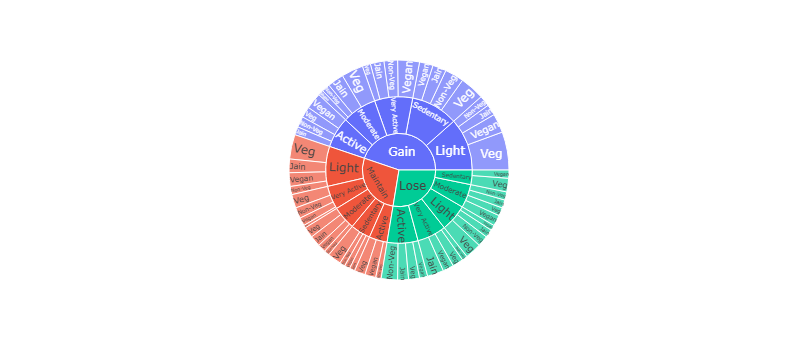

In [18]:
fig = px.sunburst(df, path=['Goal','Activity_Level','Diet_Type'])
fig.show()

In [25]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred)

[2487.04959685 2157.70956943 2568.06922264 2083.12016684 2954.9791765
 1818.62712003 2464.40634031 1746.91659981 1289.8324299  2429.77016026
 2763.32248284 2003.09536313 1958.82906013 2378.52993405 2601.89268119
 1799.57992692 1176.05228487 2113.77625303 2272.40846177 2913.37571827
 2035.35345741 1570.70125791 2247.15507335 2307.44394453 2639.33337281
 2587.95906913 2631.92595053 2555.2855755  2562.08214231 2742.96603881
 3109.94214047 3173.70167143 2407.68613955 1990.4631242  2163.04338744
 3827.01323267 1474.99842423 1750.31380872 2650.77182853 2288.72198569
 2861.84571988 1414.23956615 1880.59787837 2517.47867305 1630.33912424
 1945.58682944 2001.95912495 3168.21194842 2570.51979949 2342.95254717]


In [28]:
print(np.isnan(X_train).sum())
print(np.isnan(X_test).sum())

0
0


In [31]:
print("NaN in X_train:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\nNaN in X_test:")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

NaN in X_train:
Series([], dtype: int64)

NaN in X_test:
Age    25
dtype: int64


In [32]:
print(df.isnull().sum())

Age                          25
Gender                       25
Height_cm                     0
Weight_kg                     0
Activity_Level                0
Sleep_Hours                   0
Water_Intake_L                0
Goal                          0
Diet_Type                     0
Daily_Calorie_Requirement     0
Age_Group                    25
dtype: int64


In [33]:
print(df.dtypes)

Age                           float64
Gender                         object
Height_cm                     float64
Weight_kg                     float64
Activity_Level                 object
Sleep_Hours                   float64
Water_Intake_L                float64
Goal                           object
Diet_Type                      object
Daily_Calorie_Requirement       int64
Age_Group                    category
dtype: object


MSE: 52844.44818754257
R²: 0.8618705325930678


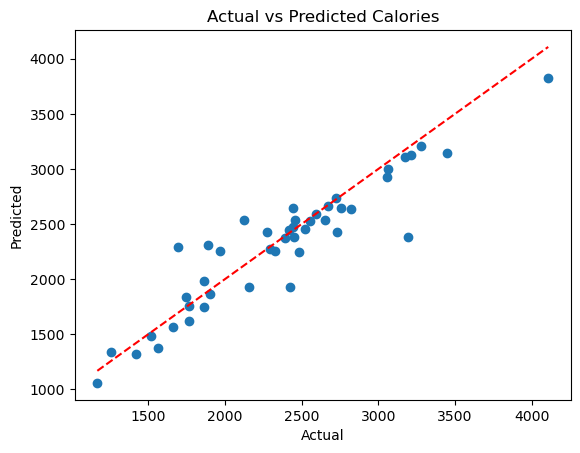

In [37]:
X = pd.get_dummies(df.drop('Daily_Calorie_Requirement', axis=1), drop_first=True)
y = df['Daily_Calorie_Requirement']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R²: {r2}")

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Calories")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()